# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Teen Social Media Usage & Mental Health** yang diperoleh dari Kaggle.

**Deskripsi Dataset:**
- **Sumber**: Kaggle (public repository)
- **Jumlah baris**: 2.500
- **Jumlah kolom**: 12
- **Tujuan**: Memprediksi risiko depresi (`depression_risk`: low/medium/high) pada remaja berdasarkan kebiasaan penggunaan media sosial dan faktor gaya hidup.

**Kolom Dataset:**
| Kolom | Tipe | Deskripsi |
|---|---|---|
| age | Integer | Usia remaja |
| gender | String | Jenis kelamin (male/female) |
| daily_social_media_hours | Float | Jam penggunaan medsos per hari |
| platform_usage | String | Platform yang digunakan (Instagram/TikTok/Both/Other) |
| sleep_hours | Float | Jam tidur per hari |
| screen_time_before_sleep | Float | Jam layar sebelum tidur |
| academic_performance | Float | Performa akademik |
| physical_activity | Float | Aktivitas fisik (jam/hari) |
| social_interaction_level | String | Level interaksi sosial (low/medium/high) |
| stress_level | Integer | Level stres (1-10) |
| anxiety_level | Integer | Level kecemasan (1-10) |
| depression_risk | String | **Target** - Risiko depresi (low/medium/high) |

# **2. Import Library**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


# **3. Memuat Dataset**

In [48]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print('Shape dataset:', df.shape)
print('\n--- 5 Baris Pertama ---')
df.head()

Shape dataset: (2500, 12)

--- 5 Baris Pertama ---


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk
0,19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium
1,16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high
2,17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low
3,19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium
4,15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low


In [49]:
print('--- Informasi Dataset ---')
df.info()

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2500 non-null   int64  
 1   gender                    2500 non-null   object 
 2   daily_social_media_hours  2500 non-null   float64
 3   platform_usage            2500 non-null   object 
 4   sleep_hours               2500 non-null   float64
 5   screen_time_before_sleep  2500 non-null   float64
 6   academic_performance      2500 non-null   float64
 7   physical_activity         2500 non-null   float64
 8   social_interaction_level  2500 non-null   object 
 9   stress_level              2500 non-null   int64  
 10  anxiety_level             2500 non-null   int64  
 11  depression_risk           2500 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 234.5+ KB


In [50]:
print('--- Statistik Deskriptif ---')
df.describe()

--- Statistik Deskriptif ---


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level
count,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,15.978000,4.45804,6.192440,1.714760,2.890944,0.991760,5.596400,5.164800
std,2.003577,2.01693,1.018734,0.716636,0.559553,0.586963,3.039013,3.002473
min,13.000000,1.00000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000
25%,14.000000,2.70000,5.500000,1.100000,2.420000,0.500000,3.000000,2.000000
50%,16.000000,4.40000,6.200000,1.700000,2.880000,1.000000,6.000000,5.000000
75%,18.000000,6.20000,6.900000,2.300000,3.340000,1.500000,8.000000,8.000000
max,19.000000,8.00000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000


# **4. Exploratory Data Analysis (EDA)**

In [51]:
# 4.1 Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

=== Missing Values ===
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
depression_risk             0
dtype: int64

Total missing values: 0


In [52]:
# 4.2 Cek duplikasi
print('=== Data Duplikat ===')
print('Jumlah duplikat:', df.duplicated().sum())

=== Data Duplikat ===
Jumlah duplikat: 0


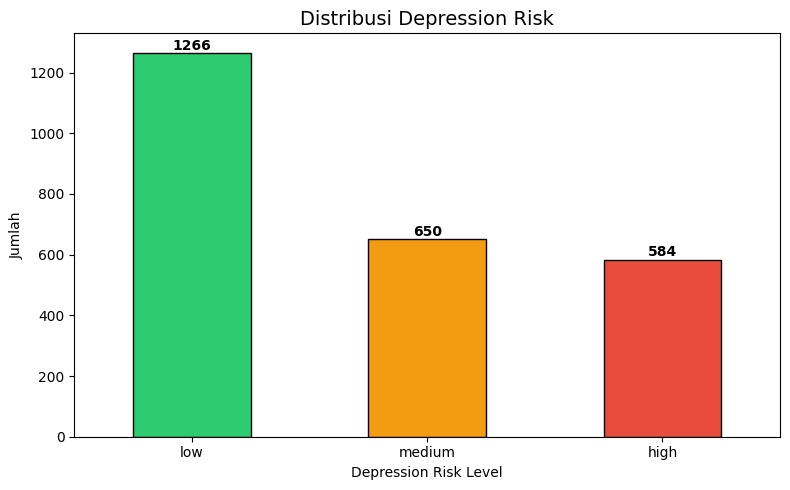

depression_risk
low       1266
medium     650
high       584
Name: count, dtype: int64


In [53]:
# 4.3 Distribusi target variable
plt.figure(figsize=(8, 5))
order = ['low', 'medium', 'high']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['depression_risk'].value_counts()[order].plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribusi Depression Risk', fontsize=14)
plt.xlabel('Depression Risk Level')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
for i, v in enumerate(df['depression_risk'].value_counts()[order]):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(df['depression_risk'].value_counts())

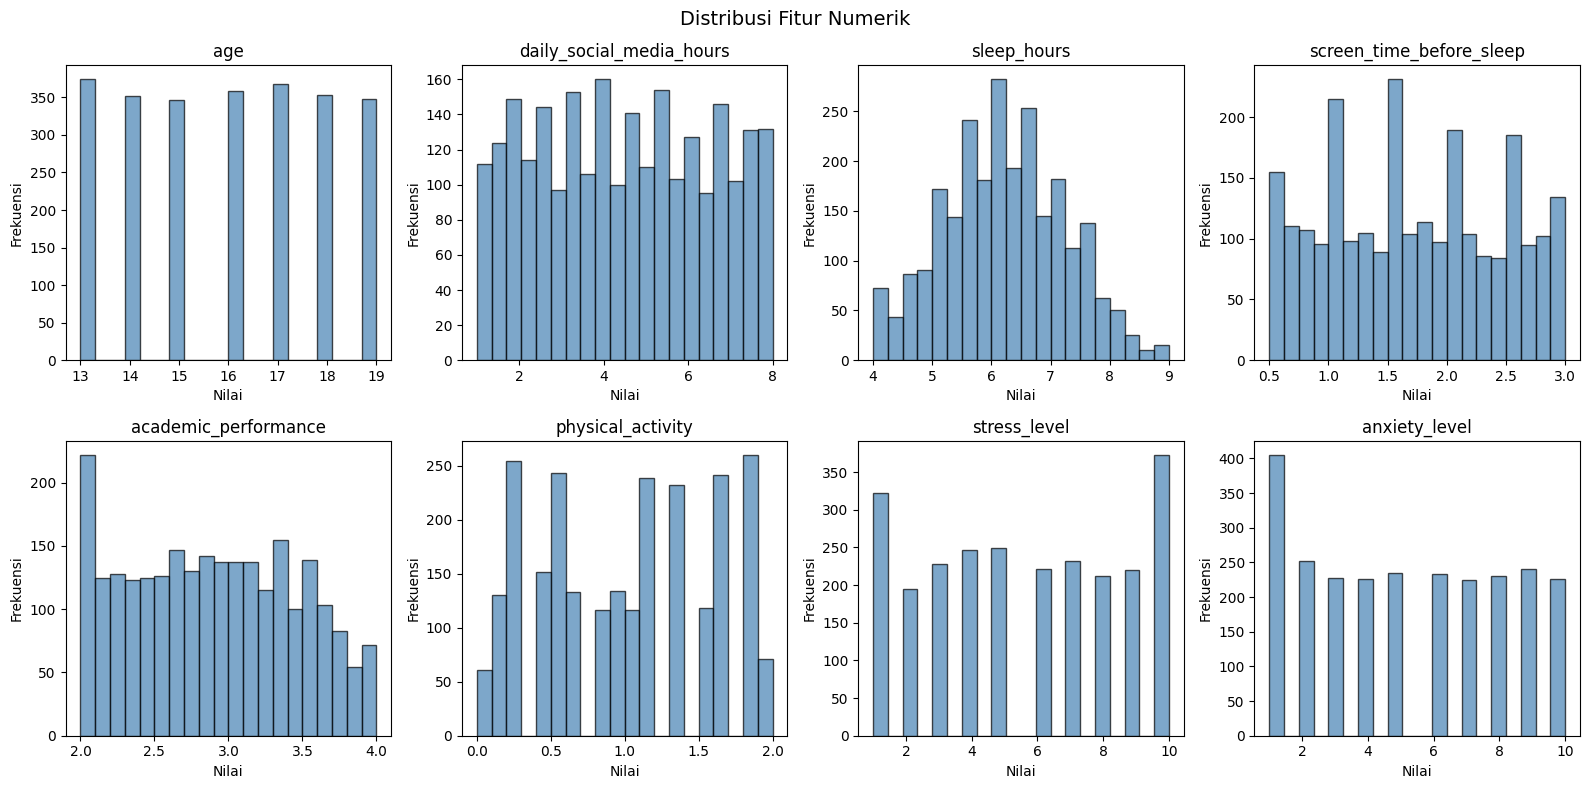

In [54]:
# 4.4 Distribusi fitur numerik
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
            'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

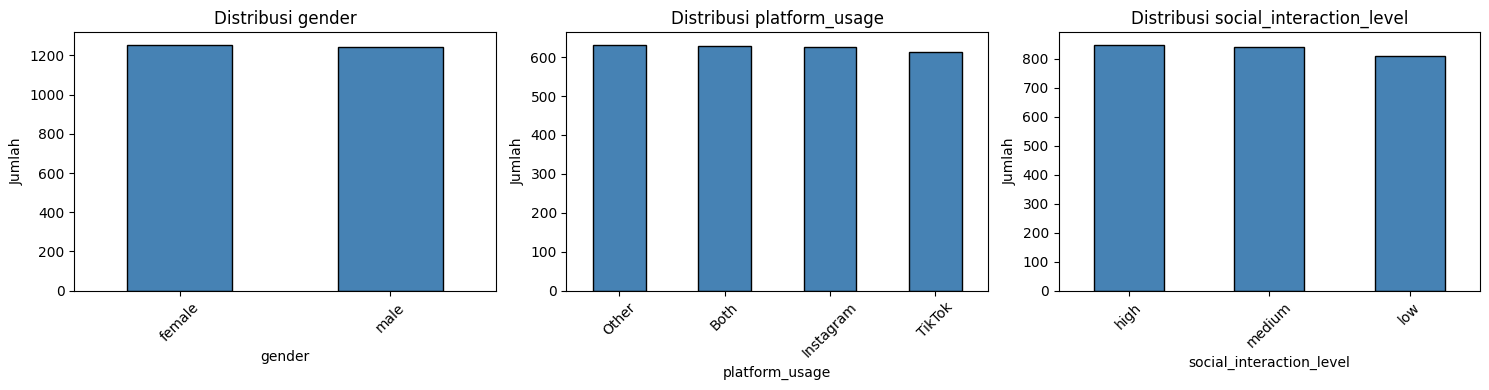

In [55]:
# 4.5 Distribusi fitur kategorikal
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

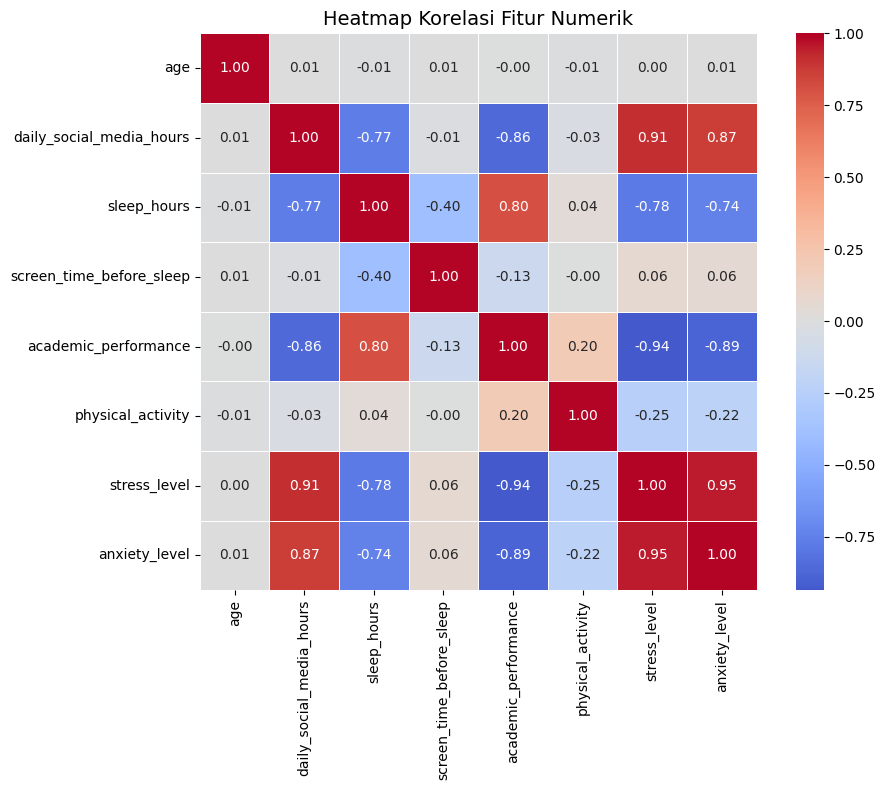

In [56]:
# 4.6 Korelasi antar fitur numerik
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

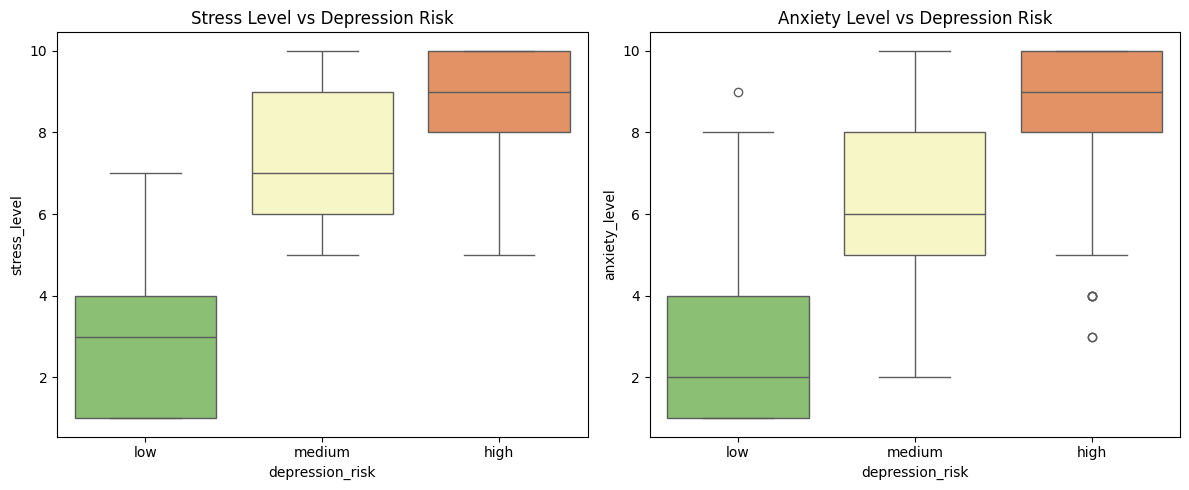

In [57]:
# 4.7 Boxplot: stress_level dan anxiety_level vs depression_risk
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = ['low', 'medium', 'high']
sns.boxplot(data=df, x='depression_risk', y='stress_level', order=order, ax=axes[0], palette='RdYlGn_r')
axes[0].set_title('Stress Level vs Depression Risk')
sns.boxplot(data=df, x='depression_risk', y='anxiety_level', order=order, ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('Anxiety Level vs Depression Risk')
plt.tight_layout()
plt.show()

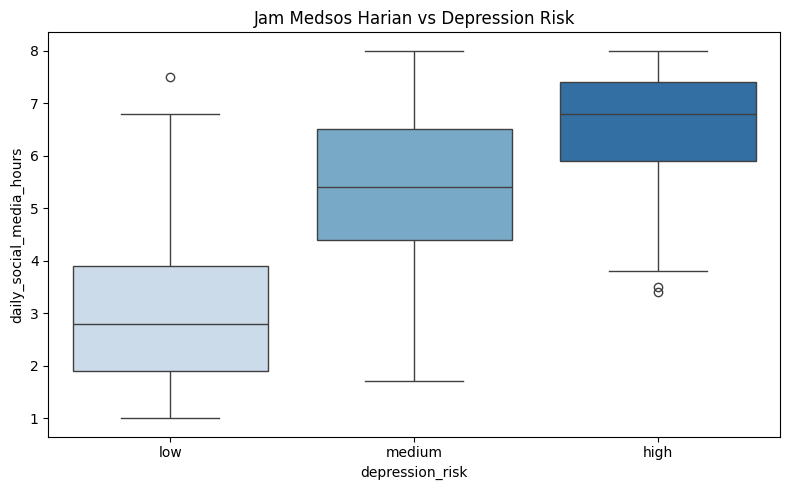

In [58]:
# 4.8 Social media hours vs depression_risk
plt.figure(figsize=(8, 5))
order = ['low', 'medium', 'high']
sns.boxplot(data=df, x='depression_risk', y='daily_social_media_hours', order=order, palette='Blues')
plt.title('Jam Medsos Harian vs Depression Risk')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

In [59]:
# 5.1 Salin dataframe agar data asli tidak berubah
df_clean = df.copy()
print('Shape awal:', df_clean.shape)

Shape awal: (2500, 12)


In [60]:
# 5.2 Tangani Missing Values
print('Missing values sebelum:', df_clean.isnull().sum().sum())

# Isi missing nilai numerik dengan median
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Isi missing nilai kategorikal dengan modus
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print('Missing values sesudah:', df_clean.isnull().sum().sum())

Missing values sebelum: 0
Missing values sesudah: 0


In [61]:
# 5.3 Hapus Duplikasi
print('Duplikat sebelum:', df_clean.duplicated().sum())
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print('Duplikat sesudah:', df_clean.duplicated().sum())
print('Shape setelah hapus duplikat:', df_clean.shape)

Duplikat sebelum: 0
Duplikat sesudah: 0
Shape setelah hapus duplikat: (2500, 12)


In [62]:
# 5.4 Encoding Fitur Kategorikal
le = LabelEncoder()

# Encode kolom-kolom kategorikal
df_clean['gender_encoded'] = le.fit_transform(df_clean['gender'])
df_clean['platform_encoded'] = le.fit_transform(df_clean['platform_usage'])
df_clean['social_interaction_encoded'] = le.fit_transform(df_clean['social_interaction_level'])

# Encode target variable
label_map = {'low': 0, 'medium': 1, 'high': 2}
df_clean['depression_risk_encoded'] = df_clean['depression_risk'].map(label_map)

print('Encoding selesai!')
print(df_clean[['gender', 'gender_encoded', 'platform_usage', 'platform_encoded']].head())

Encoding selesai!
   gender  gender_encoded platform_usage  platform_encoded
0    male               1      Instagram                 1
1    male               1          Other                 2
2  female               0          Other                 2
3  female               0         TikTok                 3
4  female               0         TikTok                 3


In [63]:
# 5.5 Normalisasi Fitur Numerik
scaler = MinMaxScaler()
cols_to_scale = ['age', 'daily_social_media_hours', 'sleep_hours',
                 'screen_time_before_sleep', 'academic_performance',
                 'physical_activity', 'stress_level', 'anxiety_level']

df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])
print('Normalisasi selesai!')
df_clean[cols_to_scale].describe()

Normalisasi selesai!


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,0.496333,0.494006,0.438488,0.485904,0.445472,0.495880,0.510711,0.462756
std,0.333930,0.288133,0.203747,0.286655,0.279776,0.293482,0.337668,0.333608
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.166667,0.242857,0.300000,0.240000,0.210000,0.250000,0.222222,0.111111
50%,0.500000,0.485714,0.440000,0.480000,0.440000,0.500000,0.555556,0.444444
75%,0.833333,0.742857,0.580000,0.720000,0.670000,0.750000,0.777778,0.777778
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [64]:
# 5.6 Pilih kolom untuk dataset final
feature_cols = cols_to_scale + ['gender_encoded', 'platform_encoded', 'social_interaction_encoded']
target_col = 'depression_risk_encoded'

df_final = df_clean[feature_cols + [target_col]].copy()
print('Shape dataset final:', df_final.shape)
df_final.head()

Shape dataset final: (2500, 12)


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,gender_encoded,platform_encoded,social_interaction_encoded,depression_risk_encoded
0,1.000000,0.400000,0.50,0.48,0.385,0.60,0.555556,0.555556,1,1,1,1
1,0.500000,0.785714,0.36,0.04,0.285,0.10,0.888889,0.666667,1,2,2,2
2,0.666667,0.271429,0.60,0.28,0.520,0.85,0.222222,0.111111,0,2,0,0
3,1.000000,0.985714,0.20,0.44,0.105,0.60,1.000000,0.777778,0,3,2,1
4,0.333333,0.028571,0.96,0.16,0.805,0.95,0.000000,0.111111,0,3,0,0


In [65]:
# 5.7 Simpan dataset yang sudah dipreprocessing
df_final.to_csv('Teen_Mental_Health_preprocessed.csv', index=False)
print('Dataset preprocessed berhasil disimpan!')
print('File: Teen_Mental_Health_preprocessed.csv')
print('Shape:', df_final.shape)

Dataset preprocessed berhasil disimpan!
File: Teen_Mental_Health_preprocessed.csv
Shape: (2500, 12)
